# 3 · The MESS echoes: signal model and arbitrary orders

MESS samples the echoes $S_k$ of the orders $k\in[k_1,k_N]$ separately. Taking $T_2$ and $T_2'$
(Lorentzian intra-voxel dephasing) into account, the paper models each echo as

$$
S_k(\text{TE}_k,\Delta\omega_0,\Delta\psi)=F_k^+\,
e^{-\text{TE}_k/T_2}\,e^{-|\text{TE}_k+k\text{TR}|/T_2'}\,
e^{i\Delta\omega_0(\text{TE}_k+k\text{TR})}\,e^{ik\Delta\psi} \qquad\text{(Eq. 3)}
$$

with $F_k^+=|F_k^+|\,e^{i[u(k)-1]\pi}$ (Eq. 2): real, positive for $k\ge0$, negative for $k<0$. Hence

$$
|S_k|=|F_k^+|\,e^{-\text{TE}_k/T_2-|\text{TE}_k+k\text{TR}|/T_2'} \quad\text{(Eq. 4a)},\qquad
\arg S_k=[u(k)-1]\pi+\Delta\omega_0(\text{TE}_k+k\text{TR})+k\Delta\psi \quad\text{(Eq. 4b)}.
$$

**The echo magnitudes do not depend on off-resonance**; all of $\Delta\omega_0$ sits in the phase.
This notebook checks both equations on a simulated brain, and then shows that an order is the
same signal no matter which sequence of the SSFP family acquires it.

In [1]:
import sys
import warnings
sys.path.insert(0, "..")
warnings.filterwarnings("ignore", module="cupy|sigpy")

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import binary_erosion
import mess
from mess import plotting, simulation as sim, theory

plotting.use_style()
CACHE = ".cache"
N_DUMMY = 2000                                    # see notebook 2

protocol = mess.MESS2D(orders=(2, -3), flip_angle=50)
phantom = sim.brain_phantom(150)

## The phantom

MR-zero's numerical brain at the protocol's resolution (150 × 150, 1.33 mm). Its voxels are
labelled WM, GM or CSF and given $T_1$, $T_2$ and $T_2'$ of Table S1 of the paper; diffusion is
off, as in the signal model. The phantom's measured $B_0$ map, with its frontal susceptibility hot
spot, is scaled to ±250 Hz to emulate high-field inhomogeneity: about five banding periods at this
TR.

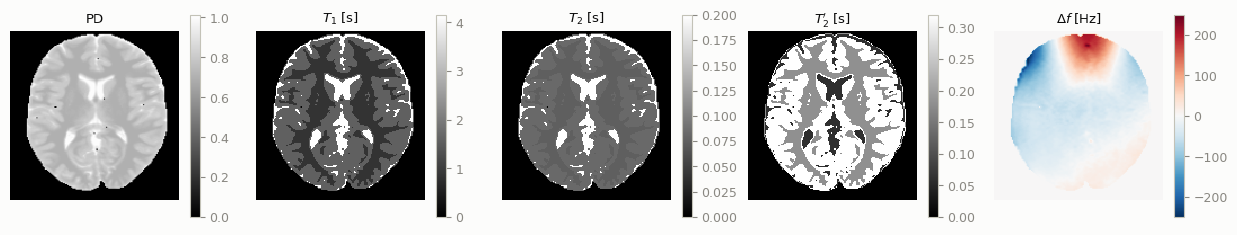

WM   T1  0.83 s   T2    75 ms   T2'  180 ms    4475 voxels
GM   T1  1.56 s   T2    83 ms   T2'  320 ms    8030 voxels
CSF  T1  4.16 s   T2  1650 ms   T2'   59 ms    1581 voxels


In [2]:
fig, axes = plt.subplots(1, 5, figsize=(12.5, 2.8))
maps = [(phantom.pd, "PD", "gray", 0, None), (phantom.t1, "$T_1$ [s]", "gray", 0, None),
        (phantom.t2, "$T_2$ [s]", "gray", 0, 0.2), (phantom.t2p, "$T_2'$ [s]", "gray", 0, None)]
for ax, (m, title, cmap, lo, hi) in zip(axes, maps):
    fig.colorbar(plotting.show(ax, np.where(phantom.pd > 0, m, 0), lo, hi, cmap, title), ax=ax, shrink=0.8)
lim = np.abs(phantom.off_resonance).max()
fig.colorbar(plotting.show(axes[4], phantom.off_resonance, -lim, lim, "RdBu_r", "$\\Delta f$ [Hz]"),
             ax=axes[4], shrink=0.8)
fig.tight_layout()
plt.show()
for name in ("WM", "GM", "CSF"):
    pd, t1, t2, t2p = sim.TABLE_S1[name]
    print(f"{name:4s} T1 {t1:5.2f} s   T2 {t2 * 1e3:5.0f} ms   T2' {t2p * 1e3:4.0f} ms   "
          f"{phantom.mask(name).sum():5d} voxels")

## The six echoes

One MESS acquisition ($\Delta\psi=0$, 2000 dummy TRs, 150 phase-encoding lines), reconstructed
echo by echo with an FFT and drawn under the readout diagram of one TR (notebook 1): each column
sits under the echo of its order. Every magnitude image is shown with its own grey scale (the
number is its maximum): there is **no banding in any echo**. The phase wraps faster the larger
$|\text{TE}_k+k\text{TR}|$, i.e. the larger $|k|$.

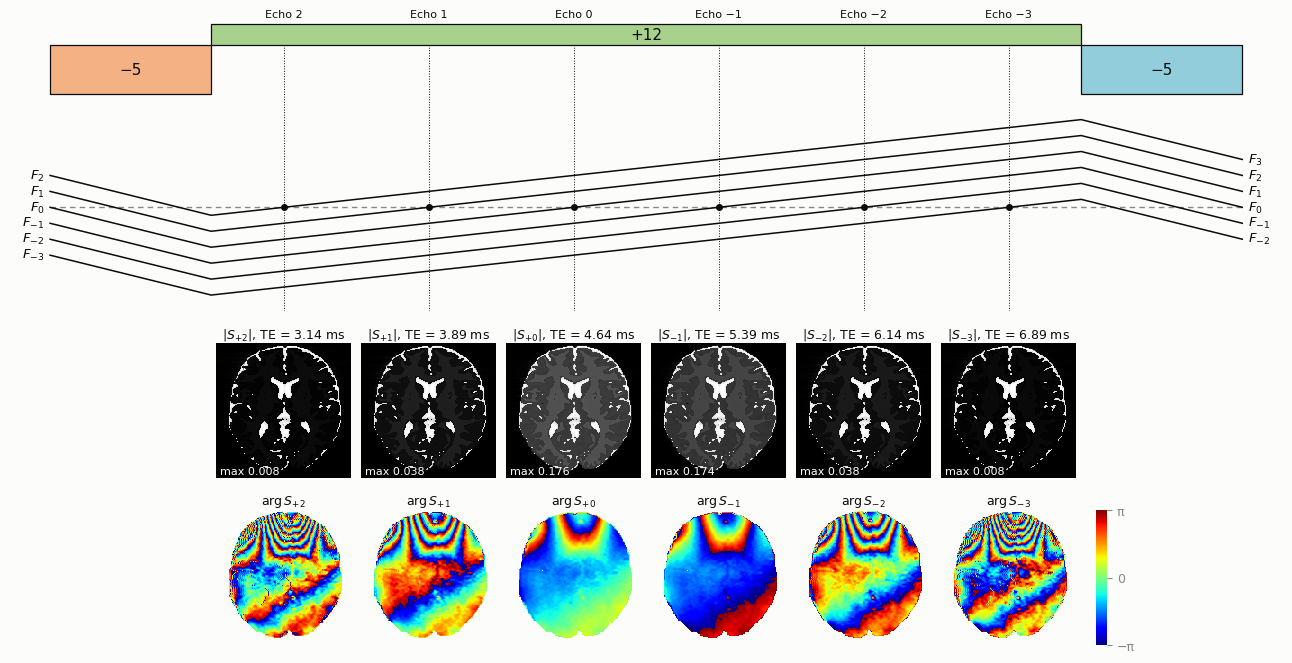

In [3]:
S = sim.reconstruct(sim.simulate(protocol.make_sequence(phase_cycle=0.0, n_dummy=N_DUMMY),
                                 phantom, CACHE), protocol)
brain = phantom.pd > 0

fig = plotting.echo_figure(protocol, S, brain)
fig.savefig("figures/mess_echoes.png", dpi=140)
plt.show()

## Check of Eq. 4a: echo magnitudes

Median of $|S_k|/\text{PD}$ over the interior of each tissue, against Eq. 4a. The images are in units
of $M_0$, so this comparison needs no scaling factor.

simulated / Eq. 4a      k=+2  k=+1  k=+0  k=-1  k=-2  k=-3
WM                    1.000  1.000  1.000  1.000  1.000  1.000
GM                    1.003  1.000  1.000  0.999  0.999  1.005
CSF                   0.998  0.999  1.000  1.000  0.999  0.998


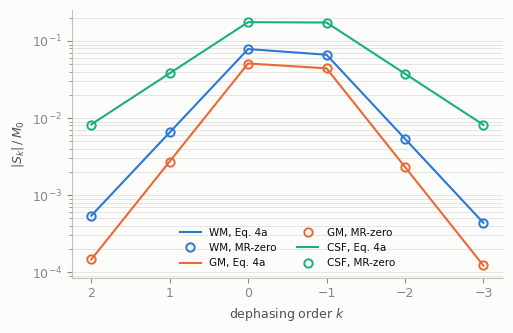

In [4]:
interior = {name: binary_erosion(phantom.mask(name), iterations=2) for name in ("WM", "GM", "CSF")}
fig, ax = plt.subplots(figsize=(5.2, 3.4))
print("simulated / Eq. 4a      " + "  ".join(f"k={k:+d}" for k in protocol.orders))
for name, m in interior.items():
    _, t1, t2, t2p = sim.TABLE_S1[name]
    model = np.abs(theory.mess_echoes(protocol.orders, protocol.te0, protocol.delta_te,
                                      protocol.flip_angle, protocol.tr, t1, t2, t2p))
    measured = np.array([np.median(np.abs(S[j])[m] / phantom.pd[m]) for j in range(protocol.n_echoes)])
    color = plotting.TISSUE_COLORS[name]
    ax.semilogy(protocol.orders, model, color=color, lw=1.5, label=f"{name}, Eq. 4a")
    ax.semilogy(protocol.orders, measured, "o", color=color, ms=6, mfc="none", mew=1.4,
                label=f"{name}, MR-zero")
    print(f"{name:4s}                  " + "  ".join(f"{r:5.3f}" for r in measured / model))
ax.set_xlabel("dephasing order $k$")
ax.set_ylabel("$|S_k|\\,/\\,M_0$")
ax.set_xticks(protocol.orders)
ax.invert_xaxis()
ax.grid(True, axis="y", which="both")
ax.legend(ncol=2, fontsize=7.5)
fig.tight_layout()
plt.show()

## Check of Eq. 4b: echo phases

By Eq. 4b the phase difference of neighbouring orders is the same for every pair,

$$
\arg\big[S_k\,\overline{S_{k-1}}\,e^{-i\Delta\psi}\big]=\mathcal W\big[\Delta\omega_0(\text{TR}-\Delta\text{TE})\big]
\quad (k\neq0),
$$

where $\mathcal W$ wraps to $(-\pi,\pi]$; for the pair $(0,-1)$ the polarity term adds $\pi$. The last
panel is the prediction from the phantom's $\Delta f$ map.

deviation from the prediction      median     voxels within 0.1 rad
  pair (+2, +1)               0.0377 rad    71.9 %
  pair (+1, +0)               0.0108 rad    91.5 %
  pair (+0, -1)               0.0061 rad    96.4 %
  pair (-1, -2)               0.0125 rad    90.3 %
  pair (-2, -3)               0.0442 rad    68.4 %


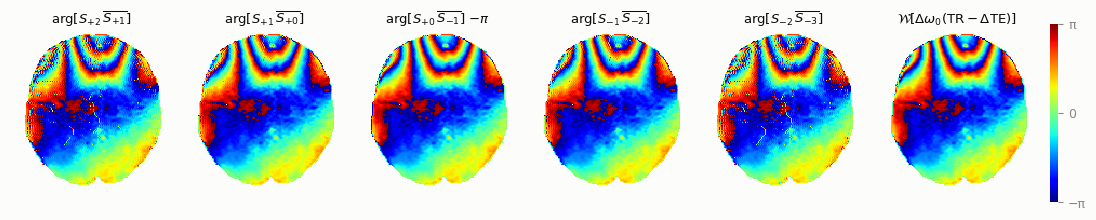

In [5]:
dw0 = 2 * np.pi * phantom.off_resonance
predicted = np.angle(np.exp(1j * dw0 * (protocol.tr - protocol.delta_te)))
fig, axes = plt.subplots(1, 6, figsize=(12.5, 2.5))
print("deviation from the prediction      median     voxels within 0.1 rad")
for ax, j in zip(axes, range(protocol.n_echoes - 1)):
    k = protocol.orders[j]
    polarity = np.pi if k == 0 else 0.0
    d = np.angle(S[j] * np.conj(S[j + 1]) * np.exp(-1j * polarity))
    err = np.abs(np.angle(np.exp(1j * (d - predicted))))[brain]
    plotting.show_phase(ax, np.where(brain, np.exp(1j * d), np.nan),
                        title=f"$\\arg[S_{{{k:+d}}}\\,\\overline{{S_{{{k - 1:+d}}}}}]$" + (" $-\\pi$" if k == 0 else ""))
    print(f"  pair ({k:+d}, {k - 1:+d})              {np.median(err):7.4f} rad   {100 * np.mean(err < 0.1):5.1f} %")
handle = plotting.show_phase(axes[-1], np.where(brain, np.exp(1j * predicted), np.nan),
                             title="$\\mathcal{W}[\\Delta\\omega_0(\\mathrm{TR}-\\Delta\\mathrm{TE})]$")
fig.tight_layout()
plotting.phase_colorbar(fig, handle, ax=list(axes), shrink=0.8, pad=0.01)
plt.show()

All five maps reproduce the prediction; the polarity term puts the extra $\pi$ exactly between
$k=0$ and $k=-1$. The remaining deviations sit where the off-resonance changes steeply from
voxel to voxel, in the frontal hot spot. There the phase of an outer order, which accrues over
the longest time $|\text{TE}_k+k\text{TR}|$, winds by a large fraction of a cycle between
neighbouring voxels, and the finite resolution mixes their phases; equivalently, the echo moves
away from the centre of its readout window. This is why the outer pairs deviate most.


## One acquisition, many SSFP sequences

Algorithm 1 can acquire any contiguous set of orders. Build FISP $[0]$, PSIF $[-1]$, DESS $[0,-1]$ and
TESS $[1,0,-1]$ with the **same TR and $\text{TE}_0$** as the six-echo MESS: then every order has the
same $\text{TE}_k$ in every sequence, and by Eq. 3 it must be the same signal. Each column below
shares one grey scale; the bSSFP image on the right is the coherent sum of all orders at
$\text{TE}=\text{TE}_0$.

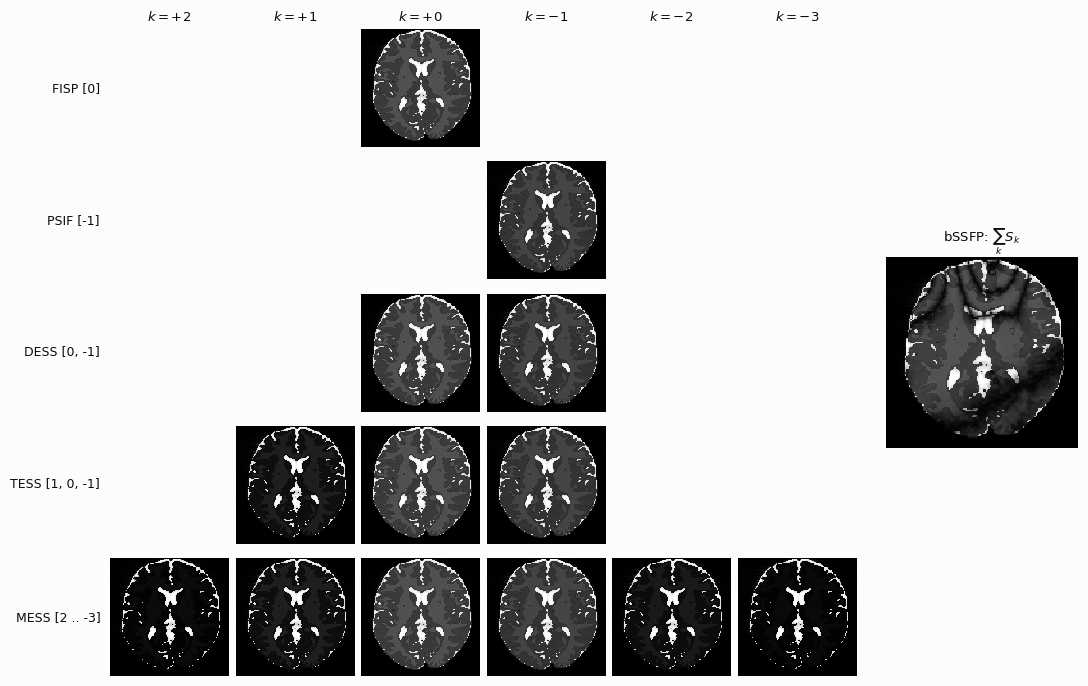

relative difference to the MESS echo of the same order
  FISP [0]        k=+0: 7.7e-04
  PSIF [-1]       k=-1: 7.3e-04
  DESS [0, -1]    k=+0: 7.7e-04  k=-1: 7.2e-04
  TESS [1, 0, -1] k=+1: 1.7e-03  k=+0: 5.3e-04  k=-1: 7.2e-04


In [6]:
family = {"FISP [0]": (0, 0), "PSIF [-1]": (-1, -1), "DESS [0, -1]": (0, -1),
          "TESS [1, 0, -1]": (1, -1), "MESS [2 .. -3]": (2, -3)}
echoes = {}
for name, orders in family.items():
    p = mess.MESS2D(orders=orders, flip_angle=50, tr=protocol.tr, te=protocol.te0)
    s = S if orders == (2, -3) else sim.reconstruct(
        sim.simulate(p.make_sequence(phase_cycle=0.0, n_dummy=N_DUMMY), phantom, CACHE), p)
    echoes[name] = dict(zip(p.orders, s))
bssfp = protocol.bssfp()
M_bssfp = sim.reconstruct(sim.simulate(bssfp.make_sequence(phase_cycle=0.0, n_dummy=N_DUMMY),
                                       phantom, CACHE), bssfp)[0]

fig = plt.figure(figsize=(12.5, 8.4))
grid = fig.add_gridspec(len(family), 8, width_ratios=[1] * 6 + [0.15, 1.6], wspace=0.05, hspace=0.12)
tops = {k: np.percentile(np.abs(echoes["MESS [2 .. -3]"][k])[brain], 99.5) for k in protocol.orders}
for r, (name, e) in enumerate(echoes.items()):
    for c, k in enumerate(protocol.orders):
        ax = fig.add_subplot(grid[r, c])
        ax.set_axis_off()
        if k in e:
            plotting.show(ax, np.abs(e[k]), vmax=tops[k])
        if r == 0:
            ax.set_title(f"$k={k:+d}$")
        if c == 0:
            ax.text(-0.08, 0.5, name, transform=ax.transAxes, ha="right", va="center")
ax = fig.add_subplot(grid[1:4, 7])
plotting.show(ax, np.abs(M_bssfp), vmax=np.percentile(np.abs(M_bssfp)[brain], 99.5),
              title="bSSFP: $\\sum_k S_k$")
plt.show()

reference = echoes["MESS [2 .. -3]"]
print("relative difference to the MESS echo of the same order")
for name, e in echoes.items():
    if name != "MESS [2 .. -3]":
        diffs = {k: np.linalg.norm((e[k] - reference[k])[brain]) / np.linalg.norm(reference[k][brain])
                 for k in e}
        print(f"  {name:16s}" + "  ".join(f"k={k:+d}: {d:.1e}" for k, d in diffs.items()))

The same pathway gives the same image whether it is acquired alone (FISP, PSIF), in pairs (DESS),
in triples (TESS) or in the six-echo train of MESS. Each echo is banding-free, while their coherent
sum, bSSFP, is not. Notebooks 4 and 5 recombine the MESS echoes into synthetic bSSFP contrast.

**Next:** [notebook 4](04_complex_sum.ipynb), the complex sum.